# How does information move through a dynamic system?
## Information theory modeling from Newtonian motion to gene expression

> **Questions throughout the article**
> External input carries some structure that changes over time. After it passes through a physical or biological dynamic system, which structures can still be read from the output, and which have been smoothed, attenuated, or recoded?

This is not a formula manual divided into chapters by discipline, but a route from **information theory problems** to **dynamic system modeling**. We ask four things repeatedly:

1. **Where does the information come from? ** What are the possible states or time patterns of the input?
2. How does the **system process input? ** What states, memories and timescales does it have?
3. **What changes are in system preferences? ** Which frequencies are amplified, attenuated or phase delayed?
4. What other judgments can the ** output support? ** Which input structures are still recoverable in the presence of noise?

<div style="padding:14px 18px;border-left:5px solid #4c78a8;background:#f3f7fb;margin:14px 0">
<b>Reading method: </b>Each chapter first asks a specific question, then uses interactive diagrams to observe the rules, and finally uses formulas to compress the rules into a transferable model. Don't memorize the formula first; first clarify what question the formula is answering.
</div>

## Learning Objectives

After completing this notebook, you should be able to:

- Use Shannon entropy to explain why "information content" comes from uncertainty, not the absolute size of the signal;
- Unify systems such as mechanical movement, protein production and degradation into an "input-state-output" model;
- Distinguish between general dynamic systems, LTI systems and local linear models of nonlinear systems;
- Explain what problems Fourier transform and Laplace transform solve respectively;
- Derive transfer functions from differential equations and read Bode magnitude and phase diagrams;
- Explain why linear systems only reweight existing frequencies, while non-linear systems can generate new frequencies;
- First use $0$ dB to establish an intuitive "frequency retention interval", and then use the output SNR to correct this approximation;
- Establish the concepts of Shannon information channel, mutual information and channel capacity, and understand their division of labor with the Bode diagram;
- Obtain a modeling language that can be transferred to subsequent cAMP frequency decoding cases.

### Full route

$$
\boxed{
\text{Uncertainty and information}
\rightarrow
\text{Dynamic state and memory}
\rightarrow
\text{Linear superposition}
\rightarrow
\text{Frequency decomposition}
\rightarrow
G(s),\,G(j\omega)
\rightarrow
\text{Bode plots}
\rightarrow
\text{Nonlinear processing}
\rightarrow
\text{Shannon information channels}
}
$$


### Operation instructions

This notebook uses:

```bash
pip install numpy scipy matplotlib bokeh biocircuits
```

By default, **angular frequency** is used throughout this article:

$$
\omega=2\pi f.
$$

- $f$: Number of cycles completed per unit time;
- $\omega$: The number of radians the phase advances per unit time;
- The horizontal axis of the Bode chart defaults to $\omega$ and uses a logarithmic scale.

Interactive graphs are powered by Bokeh's browser-side JavaScript; sliders can still be dragged after exporting to HTML. `biocircuits` is used for biological control functions, and the interactive display does not use its deprecated `interactive_xy_plot`.

In [1]:
import base64
import importlib.util
import math
import subprocess
import sys

# When running for the first time, the third-party packages required for subsequent interaction diagrams are automatically completed.
required_packages = {
    "numpy": "numpy",
    "scipy": "scipy",
    "matplotlib": "matplotlib",
    "bokeh": "bokeh",
    "biocircuits": "biocircuits",
}
missing_packages = [package for module, package in required_packages.items()
                    if importlib.util.find_spec(module) is None]
if missing_packages:
    print('Installing missing dependencies:', ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import biocircuits as bc

plt.rcParams["font.sans-serif"] = ["Hiragino Sans GB", "STHeiti", "Songti SC", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

from bokeh.embed import file_html
from bokeh.layouts import column, row
from bokeh.models import ColumnDataSource, CustomJS, Slider, Div, Span, Label
from bokeh.plotting import figure
from bokeh.resources import CDN
from IPython.display import IFrame, display

# VS Code does not render Bokeh's private MIME output; each figure is embedded in a standard HTML iframe.
# It retains the browser-side slider interaction and can also be displayed in VS Code, JupyterLab and classic Notebook.
def show(model, height=560, **_kwargs):
    html = file_html(model, CDN, 'interactive visualization')
    payload = base64.b64encode(html.encode("utf-8")).decode("ascii")
    display(IFrame(src=f'data:text/html;base64,{payload}', width='100%', height=height))

print('Environment loading completed: NumPy / SciPy / Matplotlib / Bokeh / biocircuits (VS Code compatible display)')

Environment loading completed: NumPy / SciPy / Matplotlib / Bokeh / biocircuits (VS Code compatible display)


# Chapter 1 From "information" to "dynamic system": What exactly does the system transmit?

## 1.1 The starting point of information theory: reducing uncertainty

Information theory first does not discuss "what does a sentence mean", but discusses:

> How many possibilities do we have before observing the result? After observing the results, how much uncertainty remains?

Suppose the information source generates a random variable $U$. The rarer a result $u$ is, the more informative it is when it occurs:

$$
I(u)=-\log_2 p(u).
$$

Averaging the entire information source yields Shannon entropy:

$$
\boxed{
H(U)=-\sum_u p(u)\log_2 p(u)
}
$$

The unit of entropy is **bit**. It measures not signal amplitude, nor biological importance, but "how difficult it is to guess before observing it."

For only $A/B$ there are two possible sources of binary information:

$$
H(U)=-p\log_2p-(1-p)\log_2(1-p).
$$

### Interaction 1: How does probability determine the amount of information?

**Action:** Drag $p(A)$.

**Just observe two things:**

1. Why is it the hardest to guess when $A$ and $B$ are equally likely?
2. When a certain outcome is almost certain to occur, why does the system provide little new information even though it keeps outputting it?

In [2]:
# Interaction 1: Probability and Shannon Entropy of Binary Information Sources
p_grid = np.linspace(0.001, 0.999, 500)
H_grid = -(p_grid*np.log2(p_grid) + (1-p_grid)*np.log2(1-p_grid))

p0 = 0.50
H0 = -(p0*np.log2(p0) + (1-p0)*np.log2(1-p0))

prob_src = ColumnDataSource(data=dict(symbol=['A', 'B'], prob=[p0, 1-p0]))
curve_src = ColumnDataSource(data=dict(p=p_grid, H=H_grid))
point_src = ColumnDataSource(data=dict(p=[p0], H=[H0]))

bar = figure(
    x_range=['A', 'B'], width=360, height=320,
    title='What does the information source currently output?',
    y_axis_label='probability', toolbar_location=None
)
bar.vbar(x='symbol', top='prob', width=0.65, source=prob_src)
bar.y_range.start = 0
bar.y_range.end = 1.05

curve = figure(
    width=490, height=320,
    title='Guess Difficulty: Binary Shannon Entropy',
    x_axis_label='p(A)', y_axis_label='H(U) [bit]',
    x_range=(0, 1), y_range=(0, 1.08), toolbar_location=None
)
curve.line('p', 'H', source=curve_src, line_width=3)
curve.scatter('p', 'H', source=point_src, size=13)
curve.add_layout(Span(location=1.0, dimension='width', line_dash='dotted', line_width=1.5))

p_slider = Slider(start=0.01, end=0.99, value=p0, step=0.01, title='The probability of A appearing p(A)')
entropy_info = Div(width=850)

entropy_cb = CustomJS(
    args=dict(prob_src=prob_src, point_src=point_src, slider=p_slider, info=entropy_info),
    code='\nconst p = slider.value;\nconst q = 1-p;\nfunction term(x){ return x<=0 ? 0 : -x*Math.log2(x); }\nconst H = term(p)+term(q);\n\nprob_src.data.prob = [p, q];\npoint_src.data.p = [p];\npoint_src.data.H = [H];\nprob_src.change.emit();\npoint_src.change.emit();\n\nlet interpretation = \'\';\nif(H > 0.95){\n    interpretation = \'Both outcomes are almost equally likely: the hardest to guess before observing, and a single observation can provide at most about 1 bit.\';\n}else if(H < 0.25){\n    interpretation = \'One result is almost certain: the observations are already well guessed, so new observations provide little information.\';\n}else{\n    interpretation = \'There is still uncertainty, but the two results are not symmetrical; the average information content is between 0 and 1 bit.\';\n}\ninfo.text =\n    \'<b>Current probability: </b>p(A)=\'+p.toFixed(2)+\'，p(B)=\'+q.toFixed(2)+\n    \';<b>Shannon entropy: </b>H(U)=\'+H.toFixed(3)+\' bit.<br>\'+\n    \'<b> should see: </b>\'+interpretation+\n    \'<br><span style="color:#555">Key point: A large number of outputs does not mean a large amount of information; observation will reduce uncertainty only if there are undetermined possibilities. </span>\';\n'
)
p_slider.js_on_change('value', entropy_cb)

entropy_info.text = (
    '<b>Current probability: </b>p(A)=0.50, p(B)=0.50;'
    '<b>Shannon entropy: </b>H(U)=1.000 bit. <br>'
    '<b>You should see: </b>Both results are equally possible, and it is the most difficult to guess before observation; one observation can rule out at most half of the possibilities.'
)
show(column(p_slider, row(bar, curve), entropy_info), height=500)

## 1.2 From information source to information channel

The previous section discussed **direct observation of a random variable**: the self-information $I(u)$ of the result $u$ measures how unexpected the result is this time, and the entropy $H(U)$ measures how much uncertainty about its value can be eliminated on average by observing $U$ once.

But in physical or biological systems, we often cannot directly observe what the source of information is trying to say. The information source first generates a random **message, condition, or input pattern** $M$, and then encodes it into a time signal that can enter the real system $u_M(t)$. The system processes this signal and superimposes molecular fluctuations, environmental perturbations, or measurement errors; the observer is ultimately left to infer the original message based on the noisy output trace:

$$
\boxed{
M
\xrightarrow{\text{encoding}}
u_M(t)
\xrightarrow{\text{dynamic system}}
y_M(t)
\xrightarrow{+\,N(t)}
Y_{\mathrm{obs}}(t)
\xrightarrow{\text{decoding}}
\hat M
}
$$

| Symbol | Role in the information chain |
|---|---|
| $M$ | Random messages generated by information sources, such as "low frequency pulse" or "high frequency pulse" |
| $u_M(t)$ | The physical input waveform corresponding to the message $M$, that is, the time encoding of the message |
| $y_M(t)$ | The ideal response of the dynamic system to this input |
| $N(t)$ | System inherent fluctuations, environmental disturbances or measurement noise |
| $Y_{\mathrm{obs}}(t)$ | The output trace that can actually be observed in the experiment |
| $\hat M$ | Message estimation based on output trace |

Two levels should be distinguished here: $M$ is a random variable; $u_M(t)$ is a time waveform after the message $M$ is encoded. Given $M$, $u_M(t)$ can be deterministic; if the input itself also has random fluctuations, it can be further written as a random process $U(t)$. Therefore, $u(t)$ is not simply "changing discrete random variables into continuous variables", but the **physical carrier** of information in a real system.

Before observing the output, our uncertainty about the message is $H(M)$; after observing the full output trace, the remaining uncertainty is $H(M\mid Y_{\mathrm{obs}})$. The information about the message carried by the output trace is:

$$
\boxed{
I(M;Y_{\mathrm{obs}})
=H(M)-H(M\mid Y_{\mathrm{obs}})
}
$$

$Y_{\mathrm{obs}}$ here can represent the reading at a moment or an entire output trajectory. As long as we observe that it makes the posterior probabilities of different messages more concentrated, it helps us eliminate some input possibilities.

> **The output is informative, not because it itself changes greatly, but because it helps the observer determine which message was originally sent. **

Messages can be encoded in different temporal characteristics of the input waveform:

- The level of input;
- how long the pulse lasts;
- At what point does the change occur;
- What is the period or frequency;
- How to combine multiple frequencies.

For example, $M=A$ can be encoded as a low-frequency pulse $u_A(t)$, and $M=B$ can be encoded as a high-frequency pulse $u_B(t)$. If two inputs still produce significantly different output trajectories after passing through the system, it is easy to deduce $Y_{\mathrm{obs}}(t)$ from $Y_{\mathrm{obs}}(t)$; if the system smoothes them into approximately the same output, or the difference is drowned by noise, decoding will be difficult.

The complete problem can therefore be broken down into two steps:

1. **System theory question: **How ​​does a dynamic system turn $u_M(t)$ into $y_M(t)$? Which temporal structures does it preserve and which temporal structures does it obliterate?
2. **Information theory question:** After adding noise, how much more uncertainty about $M$ can be reduced by observing $Y_{\mathrm{obs}}(t)$?

This notebook will first solve the first step: put the noise aside for the time being and figure out how the system itself processes the signal. After getting the frequency response, Chapter 7 will put back the noise, decoding and Shannon information channels.

<div style="padding:12px 16px;border-left:5px solid #4c78a8;background:#f3f7fb;margin:14px 0">
<b>The core of this transition: </b> The previous study was "How much information can be obtained by directly observing random variables"; from here we start to study "The message is first encoded into a time waveform, and then passes through the dynamic system and noise. Can we decode the original message from the output trajectory?"
</div>

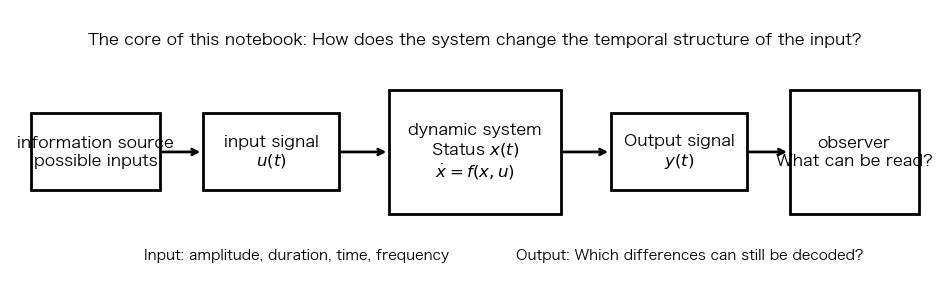

In [3]:
# Generalization from discrete messages to time-varying dynamic information channels
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 3.5)
ax.axis('off')

boxes = [
    (0.3, 1.15, 1.8, 1.0, 'information source\npossible inputs'),
    (2.7, 1.15, 1.9, 1.0, 'input signal\n$u(t)$'),
    (5.3, 0.85, 2.4, 1.6, 'dynamic system\nStatus $x(t)$\n$\\dot x=f(x,u)$'),
    (8.4, 1.15, 1.9, 1.0, 'Output signal\n$y(t)$'),
    (10.9, 0.85, 1.8, 1.6, 'observer\nWhat can be read?'),
]
for x, y, w, h, text in boxes:
    rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center', fontsize=12)

for x1, x2 in [(2.1,2.7),(4.6,5.3),(7.7,8.4),(10.3,10.9)]:
    ax.annotate('', xy=(x2,1.65), xytext=(x1,1.65),
                arrowprops=dict(arrowstyle='->', lw=2))

ax.text(6.5, 3.05, 'The core of this notebook: How does the system change the temporal structure of the input?',
        ha='center', fontsize=12, weight='bold')
ax.text(4.0, 0.25, 'Input: amplitude, duration, time, frequency', ha='center', fontsize=10.5)
ax.text(9.5, 0.25, 'Output: Which differences can still be decoded?', ha='center', fontsize=10.5)
plt.show()

## 1.3 Why does a dynamic system need "state"?

A general dynamic system is written as:

$$
\boxed{
\dot x(t)=f(x(t),u(t)),\qquad y(t)=h(x(t),u(t))
}
$$

- $u(t)$: external input;
- $x(t)$: system internal status;
- $y(t)$: observable output;
- $f$: How the state changes with the current state and input;
- $h$: How the status is read.

If only knowing the current input is not enough to predict the current output, you must know what the system has accumulated before. This "compressed record of the past" is the state.

Therefore, a dynamic system differs from an instantaneous function $y=g(u)$:

- Instantaneous functions only look at the present;
- Dynamic systems are carried through states;
- The system's memory length determines how quickly it can track changes.

The following uses a mechanical system and a biological system to illustrate: completely different mechanisms can have the same information processing structure.

## 1.4 Two seemingly different but mathematically identical systems

### Mechanical system: speed with viscous drag

$$
m\dot v(t)+bv(t)=F(t).
$$

### Biological Systems: Protein Production and Degradation

$$
\dot x(t)+\gamma x(t)=k_u u(t).
$$

Write the two equations into standard form:

$$
\tau\dot z+z=K u,
$$

You will find that both have the same structure:

| Role | Newtonian System | Production-Degradation System |
|---|---:|---:|
| Input | External force $F$ | Upstream signal $u$ |
| Status/Output | Speed $v$ | Protein Concentration $x$ |
| Memory source | Inertia $m$ | Molecular lifetime $1/\gamma$ |
| Time constant | $\tau=m/b$ | $\tau=1/\gamma$ |
| Static gain | $K=1/b$ | $K=k_u/\gamma$ |

In [4]:
# Interaction 2: Under the same pulse input, why do mechanical speed and protein concentration have isomorphic responses?
t_mem = np.linspace(0,25,1200)
u_mem = ((t_mem>=2)&(t_mem<=8)).astype(float)

def simulate_first_order(K,tau):
    z=np.zeros_like(t_mem); dt=t_mem[1]-t_mem[0]
    for i in range(1,len(t_mem)):
        z[i]=z[i-1]+dt*((K*u_mem[i-1]-z[i-1])/tau)
    return z

K0,tau0=1.6,2.0
z0=simulate_first_order(K0,tau0)
src=ColumnDataSource(data=dict(t=t_mem,u=u_mem,z=z0))

p=figure(width=850,height=360,title='Unified first-order dynamics: input accumulation, state memory and forgetting',
         x_axis_label='time',y_axis_label='normalized level')
p.line('t','u',source=src,line_width=2,line_dash='dotted',legend_label='input u(t)')
p.line('t','z',source=src,line_width=3,legend_label='state/output z(t)')
p.legend.location='top_right'
K_s=Slider(start=.2,end=3.0,value=K0,step=.05,title='Static gain K')
tau_s=Slider(start=.2,end=6.0,value=tau0,step=.1,title='time constant τ')
info=Div(width=850)
# The CustomJS slider object is named *_slider to avoid having the same name as the numerical variable in the callback.
cb=CustomJS(args=dict(src=src,K_slider=K_s,tau_slider=tau_s,info=info),code="\nconst K=K_slider.value,tau=tau_slider.value;const t=src.data.t,u=src.data.u;const z=new Array(t.length).fill(0);const dt=t[1]-t[0];\nfor(let i=1;i<t.length;i++){z[i]=z[i-1]+dt*((K*u[i-1]-z[i-1])/tau);}\nsrc.data.z=z;src.change.emit();\ninfo.text='<b>τ determines the speed: </b> After about 1τ, it is 63% complete, 3τ is 95% complete, and 5τ is close to steady state.'+\n          '<br><b>K determines the scale: </b>The steady state under constant unit input is z*=K.'+\n          '<br>In mechanical systems, τ=m/b; in production-degradation systems, τ=1/γ.';\n")
for s in [K_s,tau_s]:s.js_on_change('value',cb)
info.text='<b>Observation: </b> First change only K, then only change τ. Distinguishing "how big the output is" and "how fast the response is" is the first step in modeling.'
show(column(row(K_s,tau_s),p,info), height=530)

## 1.5 Static gain determines "how much output", and the time constant determines "how fast the response is"

In the previous section, the mechanical system and the production-degradation system were unified as:

$$
\tau\dot z+z=Ku.
$$

If the system is initially at $z(0)=0$ and receives a step input with amplitude $u_0$ at $t=0$, then:

$$
\boxed{
z(t)=Ku_0\left(1-e^{-t/\tau}\right)
}
$$

This expression clearly divides the system behavior into two parts: $K$ determines the vertical output scale, and $\tau$ determines the horizontal response time.

### Static gain $K$: How much output does the same input ultimately produce?

When time is long enough, the exponential term approaches zero:

$$
\boxed{
z(\infty)=Ku_0,
\qquad
K=\frac{z(\infty)}{u_0}
}
$$

Therefore, in the positive gain system considered in this notebook:

- $K$ Large: The same continuous input produces a larger steady-state output;
- $K$ Small: The same input produces a smaller steady-state output;
- Changing just $K$ will scale the entire response curve vertically, but will not change the time it takes for the system to respond at the same scale.

$K$ describes the overall mapping strength from input to output. Greater output does not automatically mean more information; whether it is easier to identify depends on comparing the difference in output to noise.

### Time constant $\tau$: How long does it take for the system to catch up with the input?

Divide the output by its final value:

$$
\frac{z(t)}{z(\infty)}=1-e^{-t/\tau}.
$$

After normalization, $K$ disappears, leaving only $\tau$. This means that the proportion of response completion is determined by the time constant: after approximately $1\tau$ it takes about [[KEEP_17]]] to complete $63\%$, $3\tau$ to complete $95\%$, and $5\tau$ to approach steady state.

- $\tau$ Small: The system responds quickly and can track faster input;
- $\tau$ Large: The system responds slowly and will smooth out rapid changes but retain a longer past;
- Therefore "longer memory" and "faster tracking" usually cannot be infinitely improved at the same time.

From an information processing perspective, $K$ controls how much all input differences are overall amplified or reduced; $\tau$ selects the time scale that the system can follow, thus more directly defining the system's **time information preference**.

### Standard parameters can be understood separately, but mechanism parameters may change both at the same time.

| System | Static gain $K$ | Time constant $\tau$ |
|---|---:|---:|
| Newtonian system | $1/b$ | $m/b$ |
| Production-degradation system | $k_u/\gamma$ | $1/\gamma$ |

In standard form, $K$ and $\tau$ are understood separately; but when changing the real mechanism parameters, they may change together. For example, increasing the biodegradation rate $\gamma$ will simultaneously decrease $K$ and $\tau$: the steady-state output becomes smaller, but the response and forgetting become faster. Similarly, increasing mechanical resistance $b$ simultaneously reduces the steady-state speed gain and shortens the time constant.

<div style="padding:12px 16px;border-left:5px solid #54a24b;background:#f2fbf1;margin:14px 0">
<b>Conclusion of this chapter: </b> Information comes from undetermined possibilities; dynamic systems map input differences into output differences through static gains, states, and time scales. <i>K</i> determines the overall scale of the mapping, and τ determines the memory length and trackable change speed. Although physical inertia and biomolecule lifetime have different mechanisms, they can form the same gain, memory and filtering behaviors.
</div>

# Chapter 2 Why is “linearity” a decisive demarcation?

Don't take "linear" to mean that the image looks like a straight line. For a system $T$ that maps input signals to output signals, the definition of linearity is:

$$
\boxed{T[a u_1+b u_2]=aT[u_1]+bT[u_2]}
$$

It also contains:

1. **Homogeneity**: The input is amplified $a$ times, and the output is also amplified $a$ times;
2. **Additivity**: Two inputs enter the system at the same time, and the output is equal to the sum of the two separate responses.

This means that we can first split the complex input into its simpler components, calculate them separately, and then add the results. All subsequent frequency analysis is based on this point.

The figure below only focuses on additivity in the linear definition, which is to take $a=b=1$. We compare two processing paths for the same set of inputs:

### Path A: Add the inputs first and then send them to the system

$$
u_1+u_2
\xrightarrow{T}
T[u_1+u_2].
$$

### Path B: Send them to the system separately, and then add the outputs

$$
u_1\xrightarrow{T}T[u_1],
\qquad
u_2\xrightarrow{T}T[u_2],
\qquad
T[u_1]+T[u_2].
$$

<div style="padding:12px 16px;border-left:5px solid #4c78a8;background:#f3f7fb;margin:14px 0">
<b>Graphic reading task: </b>Don't study why the output waveform is curved first, just compare whether the blue line and the orange dotted line overlap. Coincidence means that the two processing paths are equivalent, that is, they satisfy additivity; separation means that the input components interact nonlinearly in the system.
</div>

In [5]:
# Interaction 3: Are the pre- and post-overlay processes the same?
# This unit only uses Bokeh's browser-side JavaScript callbacks, so in VS Code, JupyterLab
# Draggable slider in both exported HTML; does not rely on ipywidgets kernel communication.
t_linear = np.linspace(0, 12, 1000)
A1_0, w1_0, A2_0, w2_0, phi2_0, tau_0, K_0 = 1.0, 1.0, 0.7, 2.6, 0.3, 0.7, 1.2


def first_order_filter(u, t, tau, K):
    y = np.zeros_like(u, dtype=float)
    dt = t[1] - t[0]
    for i in range(1, len(t)):
        y[i] = y[i - 1] + dt * (K * u[i - 1] - y[i - 1]) / tau
    return y


u1_0 = A1_0 * np.sin(w1_0 * t_linear)
u2_0 = A2_0 * np.sin(w2_0 * t_linear + phi2_0)
usum_0 = u1_0 + u2_0
lin_a_0 = first_order_filter(usum_0, t_linear, tau_0, K_0)
lin_b_0 = first_order_filter(u1_0, t_linear, tau_0, K_0) + first_order_filter(u2_0, t_linear, tau_0, K_0)
non_a_0 = usum_0**2
non_b_0 = u1_0**2 + u2_0**2

linear_src = ColumnDataSource(data=dict(
    t=t_linear, u1=u1_0, u2=u2_0, usum=usum_0,
    lin_a=lin_a_0, lin_b=lin_b_0, non_a=non_a_0, non_b=non_b_0,
))

input_plot = figure(width=850, height=240, title='Input: two signals and their sum',
                    x_axis_label='time', y_axis_label='amplitude', toolbar_location='above')
input_plot.line('t', 'u1', source=linear_src, line_width=2, legend_label='u₁(t)')
input_plot.line('t', 'u2', source=linear_src, line_width=2, line_dash='dashed', legend_label='u₂(t)')
input_plot.line('t', 'usum', source=linear_src, line_width=3, color='#333333', legend_label='u₁(t) + u₂(t)')
input_plot.legend.click_policy = 'hide'

linear_plot = figure(width=850, height=260, title='Linear first-order system: two paths completely coincide',
                     x_axis_label='time', y_axis_label='system output', x_range=input_plot.x_range,
                     toolbar_location='above')
linear_plot.line('t', 'lin_a', source=linear_src, line_width=4, color='#4c78a8',
                 legend_label='Path A: T[u₁ + u₂]')
linear_plot.line('t', 'lin_b', source=linear_src, line_width=2.5, line_dash='dashed', color='#f58518',
                 legend_label='Path B: T[u₁] + T[u₂]')
linear_plot.legend.click_policy = 'hide'

nonlinear_plot = figure(width=850, height=260, title='Squared nonlinearity: the two paths are no longer the same',
                        x_axis_label='time', y_axis_label='system output', x_range=input_plot.x_range,
                        toolbar_location='above')
nonlinear_plot.line('t', 'non_b', source=linear_src, line_width=2.5, line_dash='dashed', color='#f58518',
                    legend_label='Path B: u₁² + u₂²')
nonlinear_plot.line('t', 'non_a', source=linear_src, line_width=3.5, color='#e45756',
                    legend_label='Path A: (u₁ + u₂)²')
nonlinear_plot.legend.click_policy = 'hide'

A1_slider = Slider(start=0.0, end=2.0, value=A1_0, step=0.05, title='Amplitude A₁')
w1_slider = Slider(start=0.2, end=5.0, value=w1_0, step=0.1, title='Angular frequency ω₁')
A2_slider = Slider(start=0.0, end=2.0, value=A2_0, step=0.05, title='Amplitude A₂')
w2_slider = Slider(start=0.2, end=5.0, value=w2_0, step=0.1, title='Angular frequency ω₂')
phase2_slider = Slider(start=-np.pi, end=np.pi, value=phi2_0, step=0.1, title='Phase φ₂')
tau_slider = Slider(start=0.1, end=3.0, value=tau_0, step=0.05, title='time constant τ')
K_slider = Slider(start=0.1, end=3.0, value=K_0, step=0.05, title='Static gain K')
linear_info = Div(width=850)

linear_callback = CustomJS(args=dict(
    source=linear_src, A1_slider=A1_slider, w1_slider=w1_slider,
    A2_slider=A2_slider, w2_slider=w2_slider, phase2_slider=phase2_slider,
    tau_slider=tau_slider, K_slider=K_slider, info=linear_info,
), code='\nconst A1=A1_slider.value, w1=w1_slider.value, A2=A2_slider.value, w2=w2_slider.value;\nconst phi=phase2_slider.value, tau=tau_slider.value, K=K_slider.value;\nconst t=source.data.t, u1=[], u2=[], usum=[], linA=new Array(t.length).fill(0), linB=new Array(t.length).fill(0);\nconst nonA=[], nonB=[], dt=t[1]-t[0];\nfor(let i=0;i<t.length;i++){\n  const a=A1*Math.sin(w1*t[i]), b=A2*Math.sin(w2*t[i]+phi);\n  u1.push(a); u2.push(b); usum.push(a+b); nonA.push((a+b)*(a+b)); nonB.push(a*a+b*b);\n}\nfor(let i=1;i<t.length;i++){\n  linA[i]=linA[i-1]+dt*(K*usum[i-1]-linA[i-1])/tau;\n  const aPrev=u1[i-1], bPrev=u2[i-1];\n  const yaPrev=linB[i-1];\n  // Route B is updated with two independent states, so the two paths are not made identical by construction.\n}\nlet y1=0, y2=0;\nfor(let i=1;i<t.length;i++){\n  y1 += dt*(K*u1[i-1]-y1)/tau;\n  y2 += dt*(K*u2[i-1]-y2)/tau;\n  linB[i]=y1+y2;\n}\nlet maxDiff=0, maxCross=0;\nfor(let i=0;i<t.length;i++) { maxDiff=Math.max(maxDiff, Math.abs(linA[i]-linB[i])); maxCross=Math.max(maxCross, Math.abs(nonA[i]-nonB[i])); }\nsource.data.u1=u1; source.data.u2=u2; source.data.usum=usum;\nsource.data.lin_a=linA; source.data.lin_b=linB; source.data.non_a=nonA; source.data.non_b=nonB;\nsource.change.emit();\ninfo.text=\'<b>Linear system: </b>The maximum numerical difference between the two paths is\'+maxDiff.toExponential(2)+\', so superposition holds.\'+\n          \'<br><b> Square nonlinearity: </b> The difference is the cross term 2u₁u₂, and the current maximum difference is\'+maxCross.toFixed(3)+\'.\'+\n          \'<br><span style="color:#555">Changing τ or K will only change the scale and speed of the linear filter; it will not destroy the superposition. </span>\';\n')
for slider in (A1_slider, w1_slider, A2_slider, w2_slider, phase2_slider, tau_slider, K_slider):
    slider.js_on_change('value', linear_callback)

linear_info.text = ('<b>Operation: </b> First change τ or K and observe that the two curves of the linear system still coincide;'
                    'Then change the input parameters and observe how the cross terms produced by the squared nonlinearity change.')
show(column(
    row(A1_slider, w1_slider, A2_slider, w2_slider),
    row(phase2_slider, tau_slider, K_slider),
    input_plot, linear_plot, nonlinear_plot, linear_info,
), height=1020)


<div style="padding:12px 16px;border-left:5px solid #54a24b;background:#f2fbf1;margin:14px 0">
<b>Picture reading conclusion: </b>Linear systems allow us to split complex inputs into simple components, calculate the responses separately, and then add the results; for nonlinear operations such as squares, cross terms will be generated, coupling different input components to each other. The reason why Chapter 3 is able to split complex signals into different frequencies and analyze them frequency by frequency is precisely because linear systems have the ability to "disassemble, calculate and recombine".
</div>

## 2.1 LTI (Linear Time-Invariant system): linearity is not enough, the processing rules must also not change with absolute time

If the input $u(t)$ produces the output $y(t)$, and the same input is delayed by $t_0$, the output will only undergo the same time shift, and the system is called time-invariant:

$$
T[u(t-t_0)]=y(t-t_0).
$$

Time-invariant does not mean that the output cannot change with time, but it means that how the system processes the input does not depend on whether the input occurs "today or tomorrow." For example, the first-order model $\tau\dot z+z=Ku$ has a processing rule that does not rely on absolute time when $K$ and $\tau$ are constants.

Linear + time-invariant constitutes **LTI system**. The key advantages of LTI are:

> After the sine/complex exponential input passes through the system, the frequency remains unchanged and only the amplitude and phase change.

This makes each frequency a "standard test strip" for the detection system.

<div style="padding:12px 16px;border-left:5px solid #f58518;background:#fff5e9;margin:14px 0">
<b>Common misunderstandings: </b> Nonlinear systems can still be analyzed by Fourier; what is really lost is a fixed multiplicative relationship that is true for all inputs and has nothing to do with the operating point <i>Y</i>(ω) = <i>G</i>(jω)<i>U</i>(ω).
</div>

# Chapter 3 From superposition principle to frequency coordinate: Why is sine wave a natural building block of LTI system?

The previous chapter has established two key facts:

1. **Linear** allows us to split the complex input into simple components, calculate the responses separately, and then add the results;
2. **Time-invariant** means that no matter when the same input appears, the system uses the same set of rules to process it.

But to truly take advantage of these two properties, two questions need to be answered:

- Why disassemble complex input?
- There are many ways to disassemble it, why do you just disassemble it into sine waves according to frequency?

## 3.1 Step 1: Linearity makes "unpacking calculation" possible

Assume that a complex input can be written as the sum of several simple inputs:

$$
u(t)=u_1(t)+u_2(t)+\cdots+u_n(t).
$$

Since the system is linear:

$$
\boxed{
T[u_1+u_2+\cdots+u_n]
=T[u_1]+T[u_2]+\cdots+T[u_n]
}
$$

Therefore, instead of directly asking for a response to a complex input, we can work as follows:

$$
\boxed{
\text{Complex input}
\rightarrow
\text{Split into simple inputs}
\rightarrow
\text{Compute responses separately}
\rightarrow
\text{Add them back together}
}
$$

This is exactly the purpose of the overlay diagram in the last chapter: instead of just verifying an abstract formula, it provides mathematical license to "break a complex problem into many simpler problems."

## 3.2 Step 2: Why choose sine wave?

Linearity only tells us "it can be dismantled", but it does not tell us "what is the most convenient way to disassemble it". The ideal basic input should still be easily identifiable after passing through the system and not completely change into another shape.

For LTI systems, sine waves have exactly this property. If the input is:

$$
u_k(t)=A_k\cos(\omega_k t+\phi_k),
$$

The steady-state output is still a sine wave of the same frequency:

$$
T[u_k(t)]
=\widetilde A_k
\cos\!\left(\omega_k t+\widetilde\phi_k\right).
$$

The system can change amplitude and phase, but the frequency $\omega_k$ itself does not change. Therefore, each frequency component can be fed into the system separately, calculated individually, and then added to the results of other frequencies. Although linear time-varying systems still allow superposition, frequencies may be mixed; it is the combination of "linear + time-invariant" that enables frequency-by-frequency processing.

## 3.3 Fourier transform: rewrite the signal into frequency coordinates

The Fourier method tells us that a wide range of complex signals can be represented as a superposition of sinusoidal components of different frequencies. For teaching purposes, first write it in discrete summation form:

$$
u(t)=\sum_k A_k\cos(\omega_k t+\phi_k).
$$

Combined with linear superposition:

$$
T[u]
=T\!\left[\sum_k u_k\right]
=\sum_k T[u_k].
$$

The Fourier transform is then responsible for answering "what frequencies does the input consist of?":

$$
\boxed{u(t)\xrightarrow{\mathcal F}U(\omega)}
$$

It rewrites "the value at each moment" as "the amplitude and phase of each frequency". This is very similar to ordinary vector replacement coordinates: a two-dimensional vector can be described by $x/y$ components, and a time signal can be described by components at different frequencies. $U(\omega)$ is like a frequency coordinate table, recording how many components the signal has in each frequency direction.

The inverse Fourier transform resynthesizes these frequency components into time domain signals:

$$
\boxed{U(\omega)\xrightarrow{\mathcal F^{-1}}u(t)}.
$$

Fourier transform does not allow the signal to enter another physical world, but **replaces the description coordinates**.

> **Logic chain of this chapter: **Linearity allows complex inputs to be disassembled for calculation; time invariance and linearity together enable the sine wave to maintain its frequency after passing through the system; Fourier transform provides a method to split the complex input into these sine waves.

In [6]:
# Interaction 4: How do three simple frequencies synthesize a complex waveform?
tf=np.linspace(0,16,1200)
w1_0,w2_0,w3_0=1.0,2.8,5.2
A2_0,A3_0=.6,.25

def sigs(w1,w2,w3,A2,A3):
    c1=np.sin(w1*tf);c2=A2*np.sin(w2*tf+.3);c3=A3*np.sin(w3*tf-.4)
    return c1,c2,c3,c1+c2+c3
c1,c2,c3,su=sigs(w1_0,w2_0,w3_0,A2_0,A3_0)
ts=ColumnDataSource(data=dict(t=tf,c1=c1,c2=c2,c3=c3,sum=su))
ss=ColumnDataSource(data=dict(w=[w1_0,w2_0,w3_0],y0=[0,0,0],A=[1,A2_0,A3_0]))
pt=figure(width=850,height=330,title='Time domain: Complex waveforms are superpositions of simple oscillations',x_axis_label='time',y_axis_label='amplitude')
pt.line('t','c1',source=ts,line_dash='dotted',line_width=1.5,legend_label='component 1')
pt.line('t','c2',source=ts,line_dash='dashed',line_width=1.5,legend_label='component 2')
pt.line('t','c3',source=ts,line_dash='dotdash',line_width=1.5,legend_label='component 3')
pt.line('t','sum',source=ts,line_width=3,legend_label='combined')
pt.legend.click_policy='hide'
ps=figure(width=850,height=260,title='Frequency domain: The same signal only requires three spectral lines',x_axis_label='angular frequency ω',y_axis_label='amplitude',x_range=(0,8),y_range=(0,1.2))
ps.segment('w','y0','w','A',source=ss,line_width=6);ps.scatter('w','A',source=ss,size=10)
w1s=Slider(start=.4,end=2.2,value=w1_0,step=.1,title='ω1')
w2s=Slider(start=1.5,end=4.5,value=w2_0,step=.1,title='ω2')
w3s=Slider(start=3.5,end=7.5,value=w3_0,step=.1,title='ω3')
A2s=Slider(start=0,end=1,value=A2_0,step=.05,title='A2')
A3s=Slider(start=0,end=1,value=A3_0,step=.05,title='A3')
info=Div(width=850)
cb=CustomJS(args=dict(ts=ts,ss=ss,w1_slider=w1s,w2_slider=w2s,w3_slider=w3s,A2_slider=A2s,A3_slider=A3s,info=info),code="\nconst w1=w1_slider.value,w2=w2_slider.value,w3=w3_slider.value,A2=A2_slider.value,A3=A3_slider.value,t=ts.data.t;\nconst c1=[],c2=[],c3=[],sum=[];\nfor(let i=0;i<t.length;i++){const a=Math.sin(w1*t[i]);const b=A2*Math.sin(w2*t[i]+.3);const c=A3*Math.sin(w3*t[i]-.4);c1.push(a);c2.push(b);c3.push(c);sum.push(a+b+c);}\nts.data.c1=c1;ts.data.c2=c2;ts.data.c3=c3;ts.data.sum=sum;ts.change.emit();\nss.data.w=[w1,w2,w3];ss.data.A=[1,A2,A3];ss.change.emit();\ninfo.text='The time domain waveform can be complex, but the frequency domain only records the <b> position ω, amplitude A, and phase φ</b> for each component. Change a spectral line, and all moments in the time domain will change together.';\n")
for s in [w1s,w2s,w3s,A2s,A3s]:s.js_on_change('value',cb)
info.text='Try to bring the two frequencies closer together and observe the beat frequency; then adjust the high-frequency amplitude to zero and observe how the complex waveform is simplified.'
show(column(row(w1s,w2s,w3s),row(A2s,A3s),pt,ps,info), height=760)

## 3.4 Use complex exponents to write "maintain frequency, change amplitude and phase" as multiplication

In the previous section, we first used sine waves to build intuition. In order to write the amplitude change and phase shift in the same formula, the oscillation is usually represented by a complex exponential:

$$
e^{j\omega t}=\cos(\omega t)+j\sin(\omega t).
$$

For LTI systems, complex exponentials are "shape-invariant" inputs:

$$
T[e^{j\omega t}]=G(j\omega)e^{j\omega t}.
$$

$G(j\omega)$ is a plural number:

$$
G(j\omega)=|G(j\omega)|e^{j\phi(\omega)}.
$$

therefore:

- $|G(j\omega)|$: How much the frequency is amplified or reduced;
- $\phi(\omega)$: How much phase the frequency is delayed;
- The frequency $\omega$ itself does not change.

This is the mathematical basis of "split the complex input into frequencies, process it frequency by frequency, and then resynthesize it".

# Chapter 4 Laplace Transform: How to obtain system laws from differential equations?

The Fourier transform mainly deals with **which frequencies the input signal contains**. The Laplace transform mainly helps us extract the input-output relationship from the **system differential equation**.

definition:

$$
X(s)=\mathcal L\{x(t)\}=\int_0^\infty x(t)e^{-st}\,dt,
\qquad s=\sigma+j\omega.
$$

Its most critical property is to turn differentiation into multiplication:

$$
\mathcal L\{\dot x(t)\}=sX(s)-x(0).
$$

Therefore differential equations can be turned into algebraic equations. The real part $\sigma$ of $s$ describes exponential growth/decay, and the imaginary part $\omega$ describes oscillation; let $s=j\omega$ get the steady-state frequency response.

## 4.1 Newtonian system: step-by-step derivation of transfer function

Start with the velocity equation with viscous drag:

$$
m\dot v(t)+bv(t)=F(t).
$$

Laplace transform:

$$
m[sV(s)-v(0)]+bV(s)=F(s).
$$

In order to define the inherent processing rules of the system for external input, the transfer function adopts **zero initial state** $v(0)=0$:

$$
(ms+b)V(s)=F(s).
$$

then:

$$
\boxed{G(s)=\frac{V(s)}{F(s)}=\frac{1}{ms+b}}
$$

It can also be written in standard first-order form:

$$
G(s)=\frac{1/b}{1+s(m/b)}=\frac{K}{1+s\tau},
$$

in:

$$
K=\frac1b,\qquad \tau=\frac mb.
$$

<div style="padding:12px 16px;border-left:5px solid #e45756;background:#fff2f2;margin:14px 0">
<b>Transfer function and initial conditions: </b>Total response = zero input response + zero state response. The transfer function only describes the zero-state response; non-zero initial conditions are not ignored by the Laplace transform but are left alone in the <i>x</i>(0) term.
</div>

## 4.2 Before drawing the Bode diagram: first look at two real first-order systems

Transfer functions and Bode diagrams tend to appear abstract. Let’s go back to two specific questions first:

- For an object with resistance, how to establish the speed after the external force is suddenly applied?
- For a production-degradation system, how do proteins accumulate after the upstream signal is suddenly turned on?

### Physics Example: Newtonian System with Viscous Drag

$$
m\dot v+bv=F(t).
$$

If the external force jumps from $0$ to constant $F_0$ at $t=0$, and $v(0)=0$, then

$$
\boxed{
v(t)=\frac{F_0}{b}\left(1-e^{-t/(m/b)}\right)
}
$$

therefore

$$
K_{\mathrm{N}}=\frac1b,
\qquad
\tau_{\mathrm{N}}=\frac mb.
$$

- $F_0/b$ determines the final speed;
- $m/b$ determines how quickly the velocity approaches the final value.

### Biological example: protein production-degradation system

$$
\dot x=k_u u(t)-\gamma x.
$$

If the upstream signal jumps from $0$ to constant $u_0$ at $t=0$, and $x(0)=0$, then

$$
\boxed{
x(t)=\frac{k_u u_0}{\gamma}\left(1-e^{-\gamma t}\right)
}
$$

therefore

$$
K_{\mathrm{bio}}=\frac{k_u}{\gamma},
\qquad
\tau_{\mathrm{bio}}=\frac1\gamma.
$$

- $k_u u_0/\gamma$ determines the final protein level;
- $1/\gamma$ Determines the rate of protein accumulation and forgetting.

Both systems belong to the same standard first-order model:

$$
\boxed{
\tau\dot z+z=K u(t)
}
$$

For a step input, the response is

$$
z(t)=K u_0\left(1-e^{-t/\tau}\right).
$$

### Visual operation

1. Change the mass $m$, resistance $b$ and constant external force $F_0$ in a Newtonian system;
2. Change the production coefficient $k_u$, degradation rate $\gamma$ and input intensity $u_0$ in biological systems;
3. Focus on observing two things:
   - How high the curve ends up - determined by the static gain $K$;
   - How fast the curve rises - determined by the time constant $\tau$.

Dashed lines represent steady-state values, dots represent $t=\tau$. For any first-order system, a change of approximately $63.2\%$ is accomplished in $t=\tau$.

In [7]:
# Supplementary visualization: Newtonian systems and step responses of production-degradation systems
# Purpose: First see K (final height) and τ (response speed) clearly in the time domain, and then enter the Bode diagram

t_ex = np.linspace(-1.0, 8.0, 900)

# ---------- Newton system ----------
m_ex, b_ex, F0_ex = 1.4, 1.0, 1.5

def newton_step(m, b, F0):
    tp = np.maximum(t_ex, 0.0)
    tau = m / b
    v_inf = F0 / b
    force = np.where(t_ex >= 0, F0, 0.0)
    velocity = np.where(t_ex >= 0, v_inf * (1.0 - np.exp(-tp / tau)), 0.0)
    steady = np.where(t_ex >= 0, v_inf, np.nan)
    return force, velocity, steady, tau, v_inf

force_ex, velocity_ex, vsteady_ex, tau_n, vinf = newton_step(m_ex, b_ex, F0_ex)
newton_src = ColumnDataSource(data=dict(t=t_ex, inp=force_ex, out=velocity_ex, steady=vsteady_ex))
newton_tau_src = ColumnDataSource(data=dict(t=[tau_n], y=[vinf*(1-np.exp(-1))]))

p_force = figure(width=410, height=185, title='Newtonian system input: sudden application of a constant external force',
                 x_axis_label='time', y_axis_label='force F(t)', toolbar_location=None)
p_force.line('t', 'inp', source=newton_src, line_width=3)
p_force.add_layout(Span(location=0, dimension='height', line_dash='dotted', line_width=1.5))

p_velocity = figure(width=410, height=285, title='Newtonian system output: speed gradually approaches steady state',
                    x_axis_label='time', y_axis_label='velocity v(t)', toolbar_location=None)
p_velocity.line('t', 'out', source=newton_src, line_width=4, legend_label='v(t)')
p_velocity.line('t', 'steady', source=newton_src, line_width=2, line_dash='dashed',
                legend_label='steady value F₀/b')
p_velocity.scatter('t', 'y', source=newton_tau_src, size=12, legend_label='t = τ = m/b')
p_velocity.add_layout(Span(location=0, dimension='height', line_dash='dotted', line_width=1.5))
p_velocity.legend.location = 'bottom_right'

m_slider_ex = Slider(start=0.2, end=4.0, value=m_ex, step=0.05, title='mass m')
b_slider_ex = Slider(start=0.2, end=4.0, value=b_ex, step=0.05, title='Resistance b')
F_slider_ex = Slider(start=0.2, end=3.0, value=F0_ex, step=0.05, title='Constant external force F₀')
newton_info = Div(width=410)

newton_cb = CustomJS(args=dict(src=newton_src, point=newton_tau_src,
                               m_slider=m_slider_ex, b_slider=b_slider_ex,
                               F_slider=F_slider_ex, info=newton_info), code=r'''
const m=m_slider.value, b=b_slider.value, F0=F_slider.value;
const t=src.data.t;
const inp=[], out=[], steady=[];
const tau=m/b, vinf=F0/b;
for(let i=0;i<t.length;i++){
    if(t[i] < 0){
        inp.push(0); out.push(0); steady.push(NaN);
    }else{
        inp.push(F0);
        out.push(vinf*(1-Math.exp(-t[i]/tau)));
        steady.push(vinf);
    }
}
src.data.inp=inp; src.data.out=out; src.data.steady=steady;
point.data.t=[tau]; point.data.y=[vinf*(1-Math.exp(-1))];
src.change.emit(); point.change.emit();
info.text = '<b>Newton mapping</b><br>'+
  'K = 1/b = <b>'+(1/b).toFixed(2)+'</b>, &nbsp; '+
  'τ = m/b = <b>'+tau.toFixed(2)+'</b><br>'+
  'steady velocity F₀/b = <b>'+vinf.toFixed(2)+'</b><br>'+
  'At t=τ, v(t) reaches 63.2% of the steady velocity.';
''')
for s in (m_slider_ex, b_slider_ex, F_slider_ex):
    s.js_on_change('value', newton_cb)

newton_info.text = (
    f'<b>Newton mapping</b><br>K = 1/b = <b>{1/b_ex:.2f}</b>, &nbsp; '
    f'τ = m/b = <b>{tau_n:.2f}</b><br>'
    f'steady velocity F₀/b = <b>{vinf:.2f}</b><br>'
    'At t=τ, v(t) reaches 63.2% of the steady velocity.'
)

# ---------- Production–degradation system ----------
ku_ex, gamma_ex, u0_ex = 1.2, 0.8, 1.0

def bio_step(ku, gamma, u0):
    tp = np.maximum(t_ex, 0.0)
    tau = 1.0 / gamma
    x_inf = ku * u0 / gamma
    signal = np.where(t_ex >= 0, u0, 0.0)
    protein = np.where(t_ex >= 0, x_inf * (1.0 - np.exp(-gamma * tp)), 0.0)
    steady = np.where(t_ex >= 0, x_inf, np.nan)
    return signal, protein, steady, tau, x_inf

signal_ex, protein_ex, xsteady_ex, tau_bio, xinf = bio_step(ku_ex, gamma_ex, u0_ex)
bio_src = ColumnDataSource(data=dict(t=t_ex, inp=signal_ex, out=protein_ex, steady=xsteady_ex))
bio_tau_src = ColumnDataSource(data=dict(t=[tau_bio], y=[xinf*(1-np.exp(-1))]))

p_signal = figure(width=410, height=185, title='Generate-degrade input: upstream signals suddenly turn on',
                  x_axis_label='time', y_axis_label='input u(t)', toolbar_location=None)
p_signal.line('t', 'inp', source=bio_src, line_width=3)
p_signal.add_layout(Span(location=0, dimension='height', line_dash='dotted', line_width=1.5))

p_protein = figure(width=410, height=285, title='Production-Degradation Output: Protein gradually accumulates',
                   x_axis_label='time', y_axis_label='protein x(t)', toolbar_location=None)
p_protein.line('t', 'out', source=bio_src, line_width=4, legend_label='x(t)')
p_protein.line('t', 'steady', source=bio_src, line_width=2, line_dash='dashed',
               legend_label='steady value kᵤu₀/γ')
p_protein.scatter('t', 'y', source=bio_tau_src, size=12, legend_label='t = τ = 1/γ')
p_protein.add_layout(Span(location=0, dimension='height', line_dash='dotted', line_width=1.5))
p_protein.legend.location = 'bottom_right'

ku_slider_ex = Slider(start=0.2, end=3.0, value=ku_ex, step=0.05, title='Generate coefficient kᵤ')
gamma_slider_ex = Slider(start=0.2, end=3.0, value=gamma_ex, step=0.05, title='Degradation rate γ')
u_slider_ex = Slider(start=0.2, end=2.5, value=u0_ex, step=0.05, title='Upstream input u₀')
bio_info = Div(width=410)

bio_cb = CustomJS(args=dict(src=bio_src, point=bio_tau_src,
                            ku_slider=ku_slider_ex, gamma_slider=gamma_slider_ex,
                            u_slider=u_slider_ex, info=bio_info), code=r'''
const ku=ku_slider.value, gamma=gamma_slider.value, u0=u_slider.value;
const t=src.data.t;
const inp=[], out=[], steady=[];
const tau=1/gamma, xinf=ku*u0/gamma;
for(let i=0;i<t.length;i++){
    if(t[i] < 0){
        inp.push(0); out.push(0); steady.push(NaN);
    }else{
        inp.push(u0);
        out.push(xinf*(1-Math.exp(-gamma*t[i])));
        steady.push(xinf);
    }
}
src.data.inp=inp; src.data.out=out; src.data.steady=steady;
point.data.t=[tau]; point.data.y=[xinf*(1-Math.exp(-1))];
src.change.emit(); point.change.emit();
info.text = '<b>Biological mapping</b><br>'+
  'K = kᵤ/γ = <b>'+(ku/gamma).toFixed(2)+'</b>, &nbsp; '+
  'τ = 1/γ = <b>'+tau.toFixed(2)+'</b><br>'+
  'steady protein kᵤu₀/γ = <b>'+xinf.toFixed(2)+'</b><br>'+
  'At t=τ, x(t) reaches 63.2% of the steady protein level.';
''')
for s in (ku_slider_ex, gamma_slider_ex, u_slider_ex):
    s.js_on_change('value', bio_cb)

bio_info.text = (
    f'<b>Biological mapping</b><br>K = kᵤ/γ = <b>{ku_ex/gamma_ex:.2f}</b>, &nbsp; '
    f'τ = 1/γ = <b>{tau_bio:.2f}</b><br>'
    f'steady protein kᵤu₀/γ = <b>{xinf:.2f}</b><br>'
    'At t=τ, x(t) reaches 63.2% of the steady protein level.'
)

newton_panel = column(
    Div(text='<h3 style="margin:0">Physical example: force → velocity</h3>', width=410),
    p_force, p_velocity, m_slider_ex, b_slider_ex, F_slider_ex, newton_info
)
bio_panel = column(
    Div(text='<h3 style="margin:0">Biological example: signal → protein</h3>', width=410),
    p_signal, p_protein, ku_slider_ex, gamma_slider_ex, u_slider_ex, bio_info
)

bridge_html = (
    '<div style="padding:12px 16px;border-left:5px solid #59a14f;'
    'background:#f3faf1;margin-top:10px">'
    '<b>From time domain to Bode diagram: </b>'
    'A step response tells us "how long it takes the system to keep up with the input"; a Bode plot rephrases the same thing into frequency language.'
    'The cutoff angular frequency of the first-order system is <b>ω<sub>c</sub>=1/τ</b>:'
    'The larger τ, the slower the response and the narrower the passable frequency range;'
    'The smaller τ is, the faster the response is and the higher the frequency that can be tracked. </div>'
)
bridge = Div(width=850, text=bridge_html)
show(column(row(newton_panel, bio_panel), bridge), height=800)


## 4.3 From step response to $G(j\omega)$ and Bode plot

The step response just shown directly shows the steady-state gain $K$ and time constant $\tau$ of the system using an input that is suddenly turned on and held constant.

But real inputs can also continue to oscillate. At this point we need to change the question:

> How much further can the system keep up when the input oscillates at an angular frequency $\omega$? How much phase will the output lag?

For standard first-order systems

$$
G(s)=\frac{K}{1+s\tau},
$$

Let $s=j\omega$, get

$$
G(j\omega)=\frac{K}{1+j\omega\tau}.
$$

Therefore, the time scale $\tau$ in a step diagram and the cutoff angular frequency in a Bode diagram are two expressions of the same thing:

$$
\boxed{\omega_c=\frac1\tau}
$$

- Time domain: $\tau$ tells us how long it takes for the system to establish a response;
- Frequency domain: $1/\tau$ tells us what frequency level the system can track the fastest.

Let’s return to the specific parameters of the Newton system. Let $s=j\omega$:

$$
G(j\omega)=\frac{1}{b+jm\omega}.
$$

Amplitude:

$$
|G(j\omega)|=\frac{1}{\sqrt{b^2+(m\omega)^2}}.
$$

Phase:

$$
\phi(\omega)=-\arctan\frac{m\omega}{b}.
$$

The Bode plot rewrites the amplitude into decibels:

$$
20\log_{10}|G(j\omega)|.
$$

- $0\ \mathrm{dB}$: Amplitude maintenance;
- Positive dB: amplitude amplification;
- Negative dB: Amplitude attenuation;
- The cutoff corner frequency $\omega_c=1/\tau=b/m$ corresponds to the amplitude that drops to the low-frequency value $1/\sqrt2$, that is, the relative low-frequency platform decreases by $3$ dB.

In [8]:
# Interaction 5: Sinusoidal response, Bode magnitude and phase of Newtonian systems
tn=np.linspace(0,30,1800)
wb=np.logspace(-2,2,600)
m0,b0,wp0=1.2,1.0,1.0

def newton_data(m,b,wp):
    H=1/(b+1j*m*wb)
    hp=1/(b+1j*m*wp)
    F=np.sin(wp*tn)
    v=np.abs(hp)*np.sin(wp*tn+np.angle(hp))
    return F,v,20*np.log10(np.abs(H)),np.angle(H,deg=True),np.abs(hp),np.angle(hp,deg=True)
F,v,db,ph,amp,phase=newton_data(m0,b0,wp0)
ts=ColumnDataSource(data=dict(t=tn,F=F,v=v))
bs=ColumnDataSource(data=dict(w=wb,db=db,ph=ph))
point=ColumnDataSource(data=dict(w=[wp0],db=[20*np.log10(amp)],ph=[phase]))
pt=figure(width=850,height=290,title='Steady-state time domain: same frequency, different amplitudes and phases',x_axis_label='time',y_axis_label='amplitude')
pt.line('t','F',source=ts,line_width=2,legend_label='force F(t)')
pt.line('t','v',source=ts,line_width=3,line_dash='dashed',legend_label='velocity v(t)')
pt.x_range.start=0;pt.x_range.end=16
pm=figure(width=850,height=270,x_axis_type='log',title='Bode magnitude plot',x_axis_label='angular frequency ω',y_axis_label='magnitude [dB]')
pm.line('w','db',source=bs,line_width=3);pm.scatter('w','db',source=point,size=11)
pm.add_layout(Span(location=0,dimension='width',line_dash='dotted',line_width=2))
pp=figure(width=850,height=250,x_axis_type='log',title='Bode phase diagram',x_axis_label='angular frequency ω',y_axis_label='phase [degree]')
pp.line('w','ph',source=bs,line_width=3);pp.scatter('w','ph',source=point,size=11)
ms=Slider(start=.2,end=4,value=m0,step=.05,title='mass m')
bsli=Slider(start=.2,end=4,value=b0,step=.05,title='Resistance b')
wps=Slider(start=.1,end=10,value=wp0,step=.1,title='Detection angular frequency ω')
info=Div(width=850)
cb=CustomJS(args=dict(ts=ts,bs=bs,point=point,m_slider=ms,b_slider=bsli,wp_slider=wps,info=info),code="\nconst m=m_slider.value,b=b_slider.value,wp=wp_slider.value,t=ts.data.t,w=bs.data.w;const F=[],v=[];\nconst amp=1/Math.sqrt(b*b+m*m*wp*wp),phase=-Math.atan(m*wp/b);\nfor(let i=0;i<t.length;i++){F.push(Math.sin(wp*t[i]));v.push(amp*Math.sin(wp*t[i]+phase));}\nts.data.F=F;ts.data.v=v;ts.change.emit();\nconst db=[],ph=[];for(let i=0;i<w.length;i++){db.push(20*Math.log10(1/Math.sqrt(b*b+m*m*w[i]*w[i])));ph.push(-Math.atan(m*w[i]/b)*180/Math.PI);}\nbs.data.db=db;bs.data.ph=ph;bs.change.emit();point.data.w=[wp];point.data.db=[20*Math.log10(amp)];point.data.ph=[phase*180/Math.PI];point.change.emit();\nconst tau=m/b,wc=b/m;\ninfo.text='<b>Static gain: </b>1/b='+(1/b).toFixed(2)+';<b> time constant: </b>τ=m/b='+tau.toFixed(2)+';<b>Cutoff frequency: </b>ωc=b/m='+wc.toFixed(2)+\n'<br>Detection frequency |G|='+amp.toFixed(3)+', phase ='+((phase*180/Math.PI).toFixed(1))+'°. At high frequencies, objects have no time to follow the rapidly reversing external force.';\n")
for s in [ms,bsli,wps]:s.js_on_change('value',cb)
info.text='First increase the mass m: the system memory becomes longer and the cut-off frequency decreases; then increase the resistance b: the static gain decreases and the cut-off frequency increases.'
show(column(row(ms,bsli,wps),pt,pm,pp,info), height=940)

<div style="padding:12px 16px;border-left:5px solid #4c78a8;background:#f3f7fb;margin:14px 0">
<b>Conclusion of this chapter: </b> Newtonian system and production-degradation system share the same first-order step response in the time domain; Laplace transform is extracted from the differential equation <i>G</i>(<i>s</i>); <i>s</i> is limited to the imaginary axis <i>s</i> = jω to obtain the frequency response; the Bode diagram rewrites the same time constant into the gain and phase of each frequency.
</div>

# Chapter 5 Back to biological systems: production-degradation is a low-pass information channel

Linear production-degradation model:

$$
\dot x(t)=k_u u(t)-\gamma x(t).
$$

In zero initial state:

$$
sX(s)=k_uU(s)-\gamma X(s),
$$

so:

$$
\boxed{G_{\mathrm{bio}}(s)=\frac{X(s)}{U(s)}=\frac{k_u}{s+\gamma}}
$$

Written in standard form:

$$
G_{\mathrm{bio}}(s)=\frac{k_u/\gamma}{1+s/\gamma}.
$$

therefore:

$$
K=\frac{k_u}{\gamma},\qquad \tau=\frac1\gamma,\qquad \omega_c=\gamma.
$$

Biological explanation:

- Low-frequency input is maintained long enough for protein to accumulate;
- Rapid positive and negative changes or switches in high-frequency input, and the protein has no time to establish a steady state;
- Degradation is not pure "loss", it determines how quickly the system forgets the past and tracks new inputs.

In [9]:
# Interaction 6: The normalized Bode curves of the mechanical system and the biological system completely coincide
w=np.logspace(-2,2,700)
tau0=1.0
r0=w*tau0
mag0=1/np.sqrt(1+r0*r0)
phase0=-np.arctan(r0)*180/np.pi
src=ColumnDataSource(data=dict(r=r0,db=20*np.log10(mag0),ph=phase0))
pm=figure(width=850,height=300,x_axis_type='log',title='Normalized first-order systems: common frequency response of mechanical inertia and molecular lifetime',x_axis_label=r'normalized frequency  ωτ',y_axis_label='normalized magnitude [dB]')
pm.line('r','db',source=src,line_width=4,legend_label='both systems')
pm.add_layout(Span(location=-3.0103,dimension='width',line_dash='dashed',line_width=2))
pp=figure(width=850,height=260,x_axis_type='log',title='Normalized phase response',x_axis_label=r'normalized frequency  ωτ',y_axis_label='phase [degree]')
pp.line('r','ph',source=src,line_width=4)
taus=Slider(start=.2,end=5,value=tau0,step=.1,title='Actual time constant τ (changing physical frequency scale)')
info=Div(width=850)
cb=CustomJS(args=dict(tau_slider=taus,info=info),code="\nconst tau=tau_slider.value;\ninfo.text='The horizontal axis of the curve does not change after normalization by ωτ. The actual cutoff frequency is <b>ωc=1/τ='+(1/tau).toFixed(2)+'</b>.'+\n'<br>Newtonian system: τ=m/b; biological system: τ=1/γ. Different mechanisms can share the same information filtering structure.';\n")
taus.js_on_change('value',cb)
info.text='The normalized frequency ωτ=1 is the -3 dB point. The same mathematical structure does not mean the same microscopic mechanism.'
show(column(taus,pm,pp,info), height=700)

# Chapter 6 Complete LTI information processing pipeline

Now combine the previous tools. For any input:

### Input branch

$$
u(t)\xrightarrow{\mathcal F}U(\omega)
$$

Answer: What frequencies does the input contain?

### System branch

$$
\text{Differential equation}\xrightarrow{\mathcal L}G(s)\xrightarrow{s=j\omega}G(j\omega)
$$

Answer: How does the system handle each frequency?

### Convergence

$$
\boxed{Y(\omega)=G(j\omega)U(\omega)}
$$

Then through the inverse Fourier transform:

$$
Y(\omega)\xrightarrow{\mathcal F^{-1}}y(t).
$$

Note: $G(s)$ is not a "step" that the input signal goes through, but a property derived independently from the system model; it merges with the input spectrum at the multiplication point.

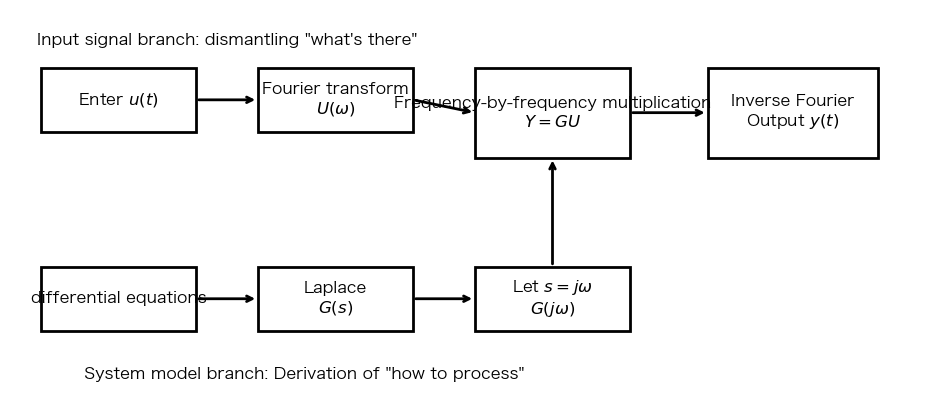

In [10]:
# Convergence diagram of system branch and input branch
fig, ax = plt.subplots(figsize=(12,5))
ax.set_xlim(0,12);ax.set_ylim(0,6);ax.axis('off')
def box(x,y,w,h,text):
    ax.add_patch(plt.Rectangle((x,y),w,h,fill=False,lw=2))
    ax.text(x+w/2,y+h/2,text,ha='center',va='center',fontsize=12)
def arrow(x1,y1,x2,y2):
    ax.annotate('',xy=(x2,y2),xytext=(x1,y1),arrowprops=dict(arrowstyle='->',lw=2))
box(.4,4.1,2,1,'Enter $u(t)$');box(3.2,4.1,2,1,'Fourier transform\n$U(\\omega)$')
box(.4,1.0,2,1,'differential equations');box(3.2,1.0,2,1,'Laplace\n$G(s)$');box(6.0,1.0,2,1,'Let $s=j\\omega$\n$G(j\\omega)$')
box(6.0,3.7,2,1.4,'Frequency-by-frequency multiplication\n$Y=GU$');box(9.0,3.7,2.2,1.4,'Inverse Fourier\nOutput $y(t)$')
arrow(2.4,4.6,3.2,4.6);arrow(5.2,4.6,6.0,4.4)
arrow(2.4,1.5,3.2,1.5);arrow(5.2,1.5,6.0,1.5);arrow(7.0,2.0,7.0,3.7);arrow(8.0,4.4,9.0,4.4)
ax.text(2.8,5.45,'Input signal branch: dismantling "what\'s there"',ha='center',fontsize=12)
ax.text(3.8,.25,'System model branch: Derivation of "how to process"',ha='center',fontsize=12)
plt.show()

In [11]:
# Interaction 7: Fourier decomposition → Bode processing → resynthesis
# For clarity of teaching, the input contains three fixed frequencies, and the system is an adjustable first-order low-pass G=K/(1+jω/ωc)
t=np.linspace(0,30,1800)
omegas=np.array([.5,2.0,6.0]);amps=np.array([1.0,.75,.55]);phases=np.array([0,.4,-.3])
K0,wc0=1.8,2.2

def pipeline(K,wc):
    H=K/(1+1j*omegas/wc)
    u=sum(a*np.sin(w*t+p) for a,w,p in zip(amps,omegas,phases))
    y=sum(a*abs(h)*np.sin(w*t+p+np.angle(h)) for a,w,p,h in zip(amps,omegas,phases,H))
    wb=np.logspace(-2,1.3,500);Hb=K/(1+1j*wb/wc)
    return u,y,H,wb,Hb
u,y,H,wb,Hb=pipeline(K0,wc0)
time=ColumnDataSource(data=dict(t=t,u=u,y=y))
spec=ColumnDataSource(data=dict(w=omegas,y0=np.zeros(3),uin=amps,yout=amps*np.abs(H)))
bode=ColumnDataSource(data=dict(w=wb,db=20*np.log10(np.abs(Hb))))
points=ColumnDataSource(data=dict(w=omegas,db=20*np.log10(np.abs(H))))
pt=figure(width=850,height=300,title='Time Domain: Input and System Output',x_axis_label='time',y_axis_label='amplitude')
pt.line('t','u',source=time,line_width=2,legend_label='input u(t)');pt.line('t','y',source=time,line_width=3,line_dash='dashed',legend_label='output y(t)');pt.x_range.end=18
ps=figure(width=850,height=270,title='Frequency domain: Each input spectral line is multiplied by the corresponding gain',x_axis_label='angular frequency ω',y_axis_label='component amplitude',x_range=(0,7),y_range=(0,3))
ps.segment('w','y0','w','uin',source=spec,line_width=5,legend_label='input components');ps.scatter('w','uin',source=spec,size=10)
ps.segment('w','y0','w','yout',source=spec,line_width=9,line_dash='dashed',legend_label='output components');ps.scatter('w','yout',source=spec,size=12,marker='diamond')
pm=figure(width=850,height=280,x_axis_type='log',title='System Bode magnitude plot versus three input frequencies',x_axis_label='angular frequency ω',y_axis_label='gain [dB]')
pm.line('w','db',source=bode,line_width=3);pm.scatter('w','db',source=points,size=12);pm.add_layout(Span(location=0,dimension='width',line_dash='dotted',line_width=2))
Ks=Slider(start=.2,end=4,value=K0,step=.05,title='Low frequency gain K')
wcs=Slider(start=.2,end=10,value=wc0,step=.1,title='Cutoff angular frequency ωc')
info=Div(width=850)
cb=CustomJS(args=dict(time=time,spec=spec,bode=bode,points=points,K_slider=Ks,wc_slider=wcs,info=info,omegas=omegas.tolist(),amps=amps.tolist(),phases=phases.tolist()),code='\nconst K=K_slider.value,wc=wc_slider.value,t=time.data.t;const u=[],y=[],outA=[],pdb=[],status=[];\nfor(let k=0;k<omegas.length;k++){const r=omegas[k]/wc,mag=K/Math.sqrt(1+r*r),ph=-Math.atan(r);outA.push(amps[k]*mag);pdb.push(20*Math.log10(mag));status.push(\'ω=\'+omegas[k].toFixed(1)+\': \'+(mag>1?\'enlarge\':mag<1?\'attenuation\':\'Keep\'));}\nfor(let i=0;i<t.length;i++){let ui=0,yi=0;for(let k=0;k<omegas.length;k++){const r=omegas[k]/wc,mag=K/Math.sqrt(1+r*r),ph=-Math.atan(r);ui+=amps[k]*Math.sin(omegas[k]*t[i]+phases[k]);yi+=amps[k]*mag*Math.sin(omegas[k]*t[i]+phases[k]+ph);}u.push(ui);y.push(yi);}\ntime.data.u=u;time.data.y=y;time.change.emit();spec.data.yout=outA;spec.change.emit();\nconst w=bode.data.w,db=[];for(let i=0;i<w.length;i++){const mag=K/Math.sqrt(1+Math.pow(w[i]/wc,2));db.push(20*Math.log10(mag));}bode.data.db=db;bode.change.emit();points.data.db=pdb;points.change.emit();\ninfo.text=\'<b>Channel-by-channel results: </b>\'+status.join(\'；\')+\'. <br>The output is not "select a frequency", but changes the amplitude and phase of each frequency separately and then adds them.\';\n')
for s in [Ks,wcs]:s.js_on_change('value',cb)
info.text='Start by using the 0 dB line to determine which frequencies are amplified or attenuated, then return to the time domain to see how these local changes collectively change the overall waveform.'
show(column(row(Ks,wcs),pt,ps,pm,info), height=930)

# Chapter 7 Nonlinear Biological Systems and Shannon Information Channel

The first six chapters establish the complete language of the LTI system: complex inputs can be decomposed into frequencies, and the system uses $G(j\omega)$ to change the amplitude and phase of each frequency respectively.

Real biological systems also need to answer three further questions:

1. The system itself is nonlinear, when can Bode diagrams be used?
2. In addition to causing analytical difficulties, can nonlinearity enable active information processing?
3. After a frequency is amplified or attenuated, how much information about the input can reach the output?

This chapter connects these three questions on the same line:

$$
\boxed{
\text{Nonlinear system}
\rightarrow
\text{Local linearisation near steady state}
\rightarrow
\text{Local Bode plot}
\rightarrow
\text{Frequency subchannels}
\rightarrow
\text{Shannon-recoverable information}
}
$$

## 7.1 Why do real biological systems need nonlinearity?

The linear production-degradation model defaults to a production rate proportional to the input. However, receptor binding, promoter occupancy, and enzymatic reactions tend to be saturated and may be cooperative. A common model is the Hill function:

$$
H(u)=\frac{u^n}{K_d^n+u^n}.
$$

Add protein degradation:

$$
\dot x=\alpha H(u)-\beta x.
$$

This is a nonlinear system because:

$$
H(a u_1+b u_2)\neq aH(u_1)+bH(u_2).
$$

Therefore, it does not have a globally fixed transfer function that holds for any input amplitude, any state, and any working interval.

## 7.2 Engineering Thinking: Why linearize near the steady state?

For a constant input $u^*$, the steady state satisfies:

$$
0=\alpha H(u^*)-\beta x^*,
\qquad
x^*=\frac{\alpha}{\beta}H(u^*).
$$

make:

$$
u=u^*+\delta u,\qquad x=x^*+\delta x.
$$

Do a first-order Taylor expansion near the working point:

$$
H(u^*+\delta u)\approx H(u^*)+H'(u^*)\delta u.
$$

Substitute and eliminate the steady-state terms:

$$
\delta\dot x=\alpha H'(u^*)\delta u-\beta\delta x.
$$

Get the local transfer function:

$$
\boxed{
G_{u^*}(s)=\frac{\delta X(s)}{\delta U(s)}
=\frac{\alpha H'(u^*)}{s+\beta}
}
$$

This means:

- **Time scale** is mainly determined by $\beta$;
- **Local sensitivity** is determined by the slope $H'(u^*)$ at the operating point;
- Changing the operating point changes the local gain, so the Bode plot is only valid for small perturbations near the operating point.

In engineering, systems that are far from steady state and continue to diverge usually do not have stable information processing functions; small perturbation models near the steady state can answer "how does the system filter information when facing normal fluctuations?"

In [12]:
# Interaction 8: Hill Curves, Work Points, Local Tangents, and Exact/Linearized Dynamics
u_grid=np.linspace(0,4,700);t_h=np.linspace(0,35,1600)
Kd0,n0,alpha0,beta0,u00,eps0,w00=1.2,3.0,2.0,.5,1.1,.25,.7

# biocircuits.act_hill(x, n) = x**n / (1 + x**n); Kd sets the input scale.
def H(u,Kd,n): return bc.act_hill(np.maximum(u,0)/Kd,n)
def dH(u,Kd,n):
    return n*Kd**n*np.maximum(u,1e-12)**(n-1)/(Kd**n+np.maximum(u,1e-12)**n)**2

def hill_dynamic(Kd,n,alpha,beta,u0,eps,w):
    inp=np.maximum(u0+eps*np.sin(w*t_h),0)
    xstar=alpha*H(u0,Kd,n)/beta;slope=dH(u0,Kd,n)
    x=np.zeros_like(t_h);xl=np.zeros_like(t_h);x[0]=xstar;xl[0]=xstar;dt=t_h[1]-t_h[0]
    for i in range(1,len(t_h)):
        x[i]=x[i-1]+dt*(alpha*H(inp[i-1],Kd,n)-beta*x[i-1])
        du=inp[i-1]-u0
        xl[i]=xl[i-1]+dt*(alpha*(H(u0,Kd,n)+slope*du)-beta*xl[i-1])
    return inp,x,xl,xstar,slope
inp,x,xl,xstar,slope=hill_dynamic(Kd0,n0,alpha0,beta0,u00,eps0,w00)
curve=ColumnDataSource(data=dict(u=u_grid,H=H(u_grid,Kd0,n0),tangent=H(u00,Kd0,n0)+slope*(u_grid-u00)))
point=ColumnDataSource(data=dict(u=[u00],H=[H(u00,Kd0,n0)]))
time=ColumnDataSource(data=dict(t=t_h,u=inp,x=x,xl=xl))
ph=figure(width=850,height=330,title='Static nonlinearity: Hill curve tangent to operating point',x_axis_label='input u',y_axis_label='activation H(u)',x_range=(0,4),y_range=(-.15,1.15))
ph.line('u','H',source=curve,line_width=4,legend_label='Hill activation');ph.line('u','tangent',source=curve,line_width=2,line_dash='dashed',legend_label='local tangent');ph.scatter('u','H',source=point,size=12)
pt=figure(width=850,height=330,title='Dynamics: Exact Nonlinear Response vs. Local Linear Response',x_axis_label='time',y_axis_label='level')
pt.line('t','u',source=time,line_width=1.5,line_dash='dotted',legend_label='input u(t)');pt.line('t','x',source=time,line_width=3,legend_label='exact x(t)');pt.line('t','xl',source=time,line_width=2,line_dash='dashed',legend_label='local linear x(t)')
Kd_s=Slider(start=.4,end=2.5,value=Kd0,step=.05,title='Half activation constant Kd')
n_s=Slider(start=1,end=6,value=n0,step=.2,title='Hill coefficient n')
u0_s=Slider(start=.15,end=3.5,value=u00,step=.05,title='Working point u*')
eps_s=Slider(start=.02,end=1.2,value=eps0,step=.02,title='Disturbance amplitude ε')
w_s=Slider(start=.1,end=3,value=w00,step=.05,title='Disturbance frequency ω')
info=Div(width=850)
cb=CustomJS(args=dict(curve=curve,point=point,time=time,Kd_slider=Kd_s,n_slider=n_s,u0_slider=u0_s,eps_slider=eps_s,w_slider=w_s,info=info),code="\nconst Kd=Kd_slider.value,n=n_slider.value,u0=u0_slider.value,eps=eps_slider.value,w=w_slider.value,alpha=2,beta=.5;\nfunction H(u){u=Math.max(u,0);return Math.pow(u,n)/(Math.pow(Kd,n)+Math.pow(u,n));}\nfunction dH(u){u=Math.max(u,1e-9);return n*Math.pow(Kd,n)*Math.pow(u,n-1)/Math.pow(Math.pow(Kd,n)+Math.pow(u,n),2);}\nconst ug=curve.data.u,hh=[],tan=[],s=dH(u0),h0=H(u0);\nfor(let i=0;i<ug.length;i++){hh.push(H(ug[i]));tan.push(h0+s*(ug[i]-u0));}\ncurve.data.H=hh;curve.data.tangent=tan;curve.change.emit();point.data.u=[u0];point.data.H=[h0];point.change.emit();\nconst t=time.data.t,inp=[],x=new Array(t.length).fill(0),xl=new Array(t.length).fill(0),dt=t[1]-t[0],xstar=alpha*h0/beta;x[0]=xstar;xl[0]=xstar;\nfor(let i=0;i<t.length;i++)inp.push(Math.max(u0+eps*Math.sin(w*t[i]),0));\nfor(let i=1;i<t.length;i++){x[i]=x[i-1]+dt*(alpha*H(inp[i-1])-beta*x[i-1]);xl[i]=xl[i-1]+dt*(alpha*(h0+s*(inp[i-1]-u0))-beta*xl[i-1]);}\ntime.data.u=inp;time.data.x=x;time.data.xl=xl;time.change.emit();\nlet err=0,scale=0;for(let i=0;i<x.length;i++){err=Math.max(err,Math.abs(x[i]-xl[i]));scale=Math.max(scale,Math.abs(x[i]-xstar));}\nconst localGain=alpha*s/beta;\ninfo.text='<b>Working point slope: </b>H′(u*)='+s.toFixed(3)+';<b>Local static gain: </b>αH′/β='+localGain.toFixed(3)+\n';<b>Maximum dynamic error: </b>'+err.toFixed(3)+'. <br>Decreasing ε improves linearization; moving the operating point changes the local sensitivity, but the cutoff frequency is still about β when β is constant.';\n")
for s in [Kd_s,n_s,u0_s,eps_s,w_s]:s.js_on_change('value',cb)
info.text='First reduce ε to verify local linearization, and then move u*: the slope in the saturation zone is small, and the slope in the intermediate transition zone is large.'
show(column(row(Kd_s,n_s,u0_s),row(eps_s,w_s),ph,pt,info), height=880)

## 7.3 When is local linearization credible?

Local linearization does not "turn a nonlinear system into a linear system", but establishes an approximation under specified conditions:

1. The system has a stable working point;
2. The input disturbance is small enough relative to the operating point;
3. The study period did not span multiple nonlinear regions;
4. Does not care about harmonics, threshold switching or multistable transitions produced by higher order terms.

If the working point changes slowly, it can be relinearized at each moment to obtain a local model that changes with the state; at this time, the transfer function also changes with the working point and is no longer globally fixed $G(s)$.

## 7.4 Nonlinearity doesn’t just “break analysis”; it can also perform computations

What a linear system does with the input frequency is:

$$
\omega_k\longrightarrow \omega_k,
$$

Only its amplitude and phase change. Nonlinear systems allow different frequencies to couple with each other.

For example:

$$
y=u+\alpha u^2,
$$

like:

$$
u=\sin\omega_1t+A\sin\omega_2t,
$$

The squared term yields:

- DC component;
- Harmonics $2\omega_1,2\omega_2$;
- sum frequency $\omega_1+\omega_2$;
- Beat frequency $|\omega_1-\omega_2|$.

So nonlinearity doesn't just make a fixed $G(j\omega)$ fail. It also converts the relationship between input frequencies into new slow variables, averages, or switching states, allowing downstream systems to read a "frequency pattern" rather than just an instantaneous amplitude.

In [13]:
# Interaction 9: Linear filtering of existing frequencies; non-linear generation of new frequencies
t=np.linspace(0,20,1400);A=.8
w10,w20,a0=1.5,3.5,0
u=np.sin(w10*t)+A*np.sin(w20*t);y=u+a0*u*u
ts=ColumnDataSource(data=dict(t=t,u=u,y=y))

def lines(w1,w2,a):
    f=[w1,w2];amp=[1,A]
    if a>1e-12:
        f += [0,2*w1,2*w2,abs(w1-w2),w1+w2]
        amp += [a*(1+A*A)/2,a/2,a*A*A/2,a*A,a*A]
    order=np.argsort(f);f=np.array(f)[order];amp=np.array(amp)[order]
    return f,amp
f,am=lines(w10,w20,a0);ss=ColumnDataSource(data=dict(w=f,y0=np.zeros_like(am),A=am))
pt=figure(width=850,height=300,title='Time Domain: Nonlinearity gradually distorts the waveform',x_axis_label='time',y_axis_label='amplitude')
pt.line('t','u',source=ts,line_width=2,legend_label='input u');pt.line('t','y',source=ts,line_width=3,line_dash='dashed',legend_label='output y')
ps=figure(width=850,height=300,title='Frequency domain: new frequencies are traces of nonlinear calculations',x_axis_label='angular frequency ω',y_axis_label='component amplitude',x_range=(0,14),y_range=(0,2.5))
ps.segment('w','y0','w','A',source=ss,line_width=5);ps.scatter('w','A',source=ss,size=10)
w1s=Slider(start=.5,end=4,value=w10,step=.1,title='ω1');w2s=Slider(start=1,end=7,value=w20,step=.1,title='ω2');asli=Slider(start=0,end=1,value=a0,step=.05,title='Nonlinear strength α')
info=Div(width=850)
cb=CustomJS(args=dict(ts=ts,ss=ss,w1_slider=w1s,w2_slider=w2s,a_slider=asli,info=info),code="\nconst w1=w1_slider.value,w2=w2_slider.value,a=a_slider.value,A=.8,t=ts.data.t,u=[],y=[];\nfor(let i=0;i<t.length;i++){const q=Math.sin(w1*t[i])+A*Math.sin(w2*t[i]);u.push(q);y.push(q+a*q*q);}ts.data.u=u;ts.data.y=y;ts.change.emit();\nlet f=[w1,w2],amp=[1,A];if(a>1e-12){f.push(0,2*w1,2*w2,Math.abs(w1-w2),w1+w2);amp.push(a*(1+A*A)/2,a/2,a*A*A/2,a*A,a*A);}\nconst idx=[...Array(f.length).keys()].sort((i,j)=>f[i]-f[j]);ss.data.w=idx.map(i=>f[i]);ss.data.y0=idx.map(i=>0);ss.data.A=idx.map(i=>amp[i]);ss.change.emit();\ninfo.text='<b>Difference frequency: </b>|ω1-ω2|='+Math.abs(w1-w2).toFixed(2)+'. When the two frequencies are close, the difference frequency becomes a slow variable; the downstream low-pass module can only retain this slow component.';\n")
for s in [w1s,w2s,asli]:s.js_on_change('value',cb)
info.text='Let α increase from 0: components appear in the spectrum that were not present in the original input. Let ω1 approach ω2 again and observe that the difference frequency moves to low frequency.'
show(column(row(w1s,w2s,asli),pt,ps,info), height=740)

## 7.5 From Bode plot to "frequency sub-channel"

For LTI systems:

$$
Y(\omega)=G(j\omega)U(\omega).
$$

This means that different Fourier modes do not mix with each other. Teaching, each frequency can be imagined as a parallel "sub-channel":

$$
U_k\longrightarrow \boxed{G(j\omega_k)}\longrightarrow Y_k.
$$

The Bode diagram is the gain table and phase delay table of these frequency sub-channels.

### First level teaching approximation: divide "Keep/Loss" in $0$ dB

To establish intuition first, temporarily assume that the input and detection thresholds have been normalized. then:

$$
|G(j\omega)|>1
\quad\Longleftrightarrow\quad
20\log_{10}|G(j\omega)|>0\ \mathrm{dB},
$$

It can be tentatively said that the frequency is "amplified and retained"; conversely, $|G(j\omega)|<1$ is tentatively said to be "attenuated and lost".

This rule simply teaches students to read Bode diagrams:

- Above $0$ dB: the output amplitude is greater than the normalized reference;
- Below $0$ dB: the output amplitude is smaller than the normalized reference.

It is not yet a strictly information theoretic conclusion. Negative gain does not mean that the signal is zero, and positive gain does not guarantee that the signal can be identified.

## 7.6 Shannon Information Channel: The system not only transmits signals, but also reduces uncertainty.

The Shannon channel focuses not on "how big" the output is, but on how much uncertainty about the input can be reduced by observing the output.

A complete information channel includes:

$$
M
\rightarrow
\text{encode as physical input }u_M(t)
\rightarrow
\boxed{\text{dynamic system}}
\rightarrow
+\,N(t)
\rightarrow
Y_{\mathrm{obs}}(t)
\rightarrow
\text{decoding}
\rightarrow
\hat M.
$$

- $M$: Random message, condition or time pattern that the sender wants to express;
- $u_M(t)$: The physical time encoding corresponding to the message $M$;
- Dynamic system: memory, filtering, amplification, attenuation or non-linear transformation of signals;
- $N(t)$: Measurement noise, molecular fluctuations or environmental disturbances;
- $Y_{\mathrm{obs}}(t)$: The output trajectory actually seen by the receiving end;
- $\hat M$: The message inferred by the receiving end based on the output trajectory.

Given the encoding scheme and the dynamic system, the entire channel is described by a conditional distribution $p(Y_{\mathrm{obs}}\mid M)$. The information shared by messages and observation outputs is mutual information:

$$
I(M;Y_{\mathrm{obs}})=H(M)-H(M\mid Y_{\mathrm{obs}}).
$$

Given the system, allowed encodings, and constraints, when choosing optimal message statistics, the maximum message that can be reliably delivered is called the channel capacity:

$$
\boxed{C=\max_{p(m)}I(M;Y_{\mathrm{obs}})}.
$$

therefore:

> **Bode diagram answers how the dynamic system changes each frequency; Shannon information channel answers how much input uncertainty can be reliably eliminated after passing through the system and noise. **

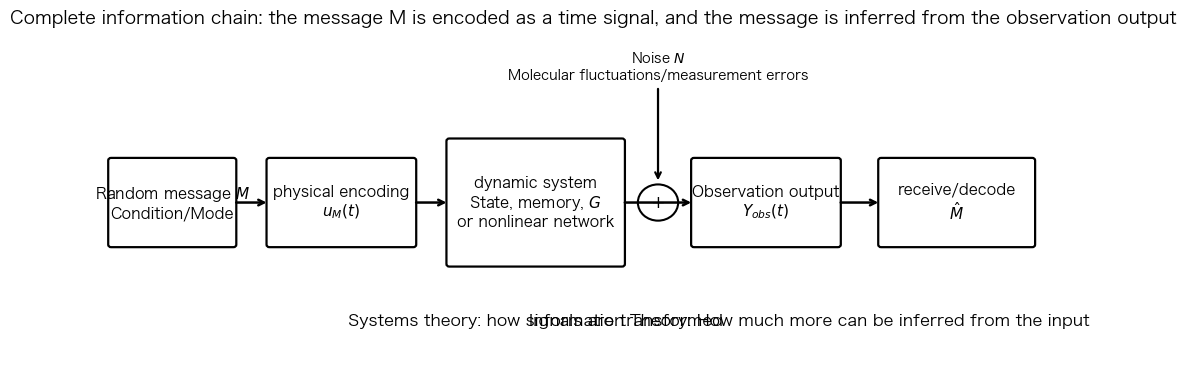

In [14]:
# Visualization 10: Correspondence between Shannon information channels and dynamic systems
from matplotlib.patches import FancyBboxPatch, Circle

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')

boxes = [
    (0.3, 1.8, 1.7, 1.3, 'Random message $M$\nCondition/Mode'),
    (2.5, 1.8, 2.0, 1.3, 'physical encoding\n$u_M(t)$'),
    (5.0, 1.5, 2.4, 1.9, 'dynamic system\nState, memory, $G$\nor nonlinear network'),
    (8.4, 1.8, 2.0, 1.3, 'Observation output\n$Y_{obs}(t)$'),
    (11.0, 1.8, 2.1, 1.3, 'receive/decode\n$\\hat M$'),
]
for x,y,w,h,label in boxes:
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle='round,pad=0.04',facecolor='white',edgecolor='black',linewidth=1.6))
    ax.text(x+w/2,y+h/2,label,ha='center',va='center',fontsize=11)

for x0,x1 in [(2.0,2.5),(4.5,5.0),(7.4,8.4),(10.4,11.0)]:
    ax.annotate('',xy=(x1,2.45),xytext=(x0,2.45),arrowprops=dict(arrowstyle='->',lw=1.8))

ax.add_patch(Circle((7.9,2.45),0.28,facecolor='white',edgecolor='black',linewidth=1.5))
ax.text(7.9,2.45,'+',ha='center',va='center',fontsize=14)
ax.annotate('',xy=(7.9,2.75),xytext=(7.9,4.25),arrowprops=dict(arrowstyle='->',lw=1.6))
ax.text(7.9,4.55,'Noise $N$\nMolecular fluctuations/measurement errors',ha='center',va='center',fontsize=10)

ax.text(6.2,0.55,'Systems theory: how signals are transformed',ha='center',fontsize=12,fontweight='bold')
ax.text(10.0,0.55,'Information Theory: How much more can be inferred from the input',ha='center',fontsize=12,fontweight='bold')
ax.set_title('Complete information chain: the message M is encoded as a time signal, and the message is inferred from the observation output',fontsize=13,pad=10)
plt.show()


## 7.7 From output SNR to Shannon capacity

If the power of the $k$th input frequency is $P_k$ and the noise power of this frequency at the output end is $N_k$, then the frequency sub-channel can be written as:

$$
Y_k=G(j\omega_k)U_k+N_k,
$$

Its output signal-to-noise ratio is:

$$
\boxed{
\mathrm{SNR}_k
=\frac{|G(j\omega_k)|^2P_k}{N_k}
}
$$

This corrects the $0$ dB approximation:

- If the frequency of $|G|<1$ is still much higher than the noise, the input may still be reliably restored;
- If the frequency of $|G|>1$ is very noisy, the receiving end may still not be able to recognize it;
- Changing the noise will not change the Bode plot, but it will change the information that the channel can convey.

For a real additive Gaussian noise sub-channel, under a given average power constraint, its Shannon capacity contribution is:

$$
\boxed{
C_k=\frac12\log_2(1+\mathrm{SNR}_k)
\quad \text{bit / channel use}
}
$$

For an ideal bandlimited AWGN channel with bandwidth $B$, total signal power $S$, and total noise power $N$, the classic Shannon–Hartley formula is:

$$
\boxed{
C=B\log_2\left(1+\frac{S}{N}\right)
\quad \text{bit/s}
}
$$

These two formulas use different measurement units and channel division methods, but express the same core rule:

> Bandwidth provides the independently varying dimensions available, and SNR determines how many levels can be reliably distinguished in each dimension.

In biological systems, assumptions such as Gaussian, independent frequencies, and optimal coding may not strictly hold. So these formulas are first and foremost a **standard reference model**: it unifies Bode gain, input power and noise into the metric "recoverable information".

In [15]:
# Interaction 10: Coarse 0 dB to Shannon frequency subchannel capacity
omegas=np.array([.5,2.0,6.0]);Pin=np.array([.5,.5,.5]);K0,wc0,sig0=1.8,2.2,.25
wb=np.logspace(-2,1.2,500)
def info_data(K,wc,sigma):
    H=K/(1+1j*omegas/wc);Hb=K/(1+1j*wb/wc)
    snr=np.abs(H)**2*Pin/(sigma*sigma)
    bits=.5*np.log2(1+snr)
    return H,Hb,snr,bits
H,Hb,snr,bits=info_data(K0,wc0,sig0)
bode=ColumnDataSource(data=dict(w=wb,db=20*np.log10(np.abs(Hb))))
pts=ColumnDataSource(data=dict(w=omegas,db=20*np.log10(np.abs(H))))
bar=ColumnDataSource(data=dict(w=omegas,y0=np.zeros(3),bits=bits,snr=snr))
pm=figure(width=850,height=300,x_axis_type='log',title='First layer: Bode gain and 0 dB teaching boundary',x_axis_label='angular frequency ω',y_axis_label='gain [dB]')
pm.line('w','db',source=bode,line_width=3);pm.scatter('w','db',source=pts,size=13);pm.add_layout(Span(location=0,dimension='width',line_dash='dotted',line_width=2))
pi=figure(width=850,height=300,title='Second layer: Shannon capacity contribution of Gaussian sub-channels at each frequency',x_axis_label='angular frequency ω',y_axis_label='Ck = 0.5 log2(1+SNRk) [bit/use]',x_range=(0,7),y_range=(0,7))
pi.segment('w','y0','w','bits',source=bar,line_width=10);pi.scatter('w','bits',source=bar,size=13)
Ks=Slider(start=.2,end=4,value=K0,step=.05,title='Low frequency gain K');wcs=Slider(start=.2,end=10,value=wc0,step=.1,title='Cutoff angular frequency ωc');sigs=Slider(start=.03,end=1,value=sig0,step=.01,title='Output noise standard deviation σ')
info=Div(width=850)
cb=CustomJS(args=dict(bode=bode,pts=pts,bar=bar,K_slider=Ks,wc_slider=wcs,sigma_slider=sigs,info=info,omegas=omegas.tolist(),Pin=Pin.tolist()),code="\nconst K=K_slider.value,wc=wc_slider.value,s=sigma_slider.value,w=bode.data.w,db=[],pdb=[],snr=[],bits=[],coarse=[];\nfor(let i=0;i<w.length;i++){const mag=K/Math.sqrt(1+Math.pow(w[i]/wc,2));db.push(20*Math.log10(mag));}bode.data.db=db;bode.change.emit();\nlet total=0;for(let k=0;k<omegas.length;k++){const mag=K/Math.sqrt(1+Math.pow(omegas[k]/wc,2));const d=20*Math.log10(mag);pdb.push(d);const q=mag*mag*Pin[k]/(s*s);snr.push(q);const b=.5*Math.log2(1+q);bits.push(b);total+=b;coarse.push('ω='+omegas[k].toFixed(1)+(d>=0?': 0 dB or more':': 0 dB or less'));}\npts.data.db=pdb;pts.change.emit();bar.data.snr=snr;bar.data.bits=bits;bar.change.emit();\ninfo.text='<b>0 dB Rough judgment: </b>'+coarse.join('；')+'. <br><b>Shannon sub-channel model: </b>Total capacity contribution='+total.toFixed(3)+'bit/use. When only the noise is changed, the Bode plot remains unchanged, but the recoverable information changes significantly.';\n")
for s in [Ks,wcs,sigs]:s.js_on_change('value',cb)
info.text='Key experiment: fix K and ωc, and only add noise. The Bode diagram of the system remains completely unchanged, but the Shannon capacity decreases - this shows that the Bode diagram is not the channel capacity itself.'
show(column(row(Ks,wcs,sigs),pm,pi,info), height=740)

## 7.8 Four concepts that must be separated

| Concept | Answered Questions | Typical Quantities |
|---|---|---|
| Input Spectrum | What does the input actually contain? | $U(\omega)$, $P_u(\omega)$ |
| System frequency response | How does the system change frequencies? | $G(j\omega)$, Bode diagram |
| Output signal-to-noise ratio | Is the changed signal higher than the noise? | $|G|^2P_u/P_n$ |
| Shannon Information Channel | How much message uncertainty can be reduced by observing the output? | $I(M;Y_{\mathrm{obs}})$, $C=\max I(M;Y_{\mathrm{obs}})$ |

So the final expression should be:

> **Bode diagram describes the frequency preference of the system; the input spectrum tells us where the information is placed; the noise determines whether these differences are still discernible; Shannon information theory combines the three into mutual information and channel capacity. **

<div style="padding:12px 16px;border-left:5px solid #b279a2;background:#faf3fb;margin:14px 0">
<b>Interface to cAMP notebook: </b>This notebook has established language for "state and memory, low pass, operating point, local linearization, mixing, frequency subchannels and Shannon recoverable information". The subsequent cAMP case will study how multiple nonlinear modules convert different pulse frequencies of the same molecular signal into different gene expression outputs.
</div>

# Chapter 8 Common Misunderstandings Checklist

1. **"Bigger output, so more information."**
   Wrong. The distance between output classes must be judged relative to the noise.

2. **"$|G|<1$ has no information."**
   Just a first-level approximation under the normalized threshold model. A strict judgment requires input power and noise.

3. **“Fourier transform can only be used for linear systems.”**
   Wrong. Spectrum analysis can also be done on the input and output of nonlinear systems; it is just that frequency-by-frequency independent multiplication cannot be completed with a fixed $G$.

4. **“The Laplace transform is equal to the Fourier transform.”**
   Fourier mainly describes the steady-state frequency composition; Laplace adds exponential growth/decay, which can handle initial values and transient states, and extract system laws from differential equations. Fourier can be viewed as a slice of $s=j\omega$ when the conditions are met.

5. **“Nonlinear systems also have a global Bode diagram.”**
   Usually no. In engineering, the local frequency response, description function or measured frequency response under the specified operating point and disturbance amplitude is often used.

6. **“After linearization, the original system is linear.”**
   Wrong. Linearization only holds approximately within a small region of state space near the operating point.

7. **“Biodegradation is just a loss of signal.”**
   Degradation simultaneously defines memory length, response speed, and passable frequency range.

# Exploration tasks

These tasks are suitable as supplementary exercises after lectures and do not need to be completed all at once.

### Task A: Parameters and Mechanisms

For the Newtonian system, change $m$ and $b$ respectively, answer:

- Which parameter mainly changes the static gain?
- Which parameter extends memory?
- Why does increasing $b$ simultaneously reduce low-frequency speed gain and increase cutoff frequency?

### Task B: Same Bode, different information

Fixed $G(j\omega)$, only changes input power or noise. Construct two systems: their Bode plots are identical, but the recoverable information is significantly different.

### Task C: Boundary of local model

Select three operating points in the Hill interaction: low input zone, transition zone, and saturation zone. Compare:

- $H'(u^*)$;
- Local static gain;
- Exact model and linear model errors;
- When does failure begin after the disturbance amplitude increases.

# Final summary

This interdisciplinary thread can be condensed into one sentence:

$$
\boxed{
\text{Dynamic systems map input differences to output differences;}
\quad
\text{systems theory describes the mapping, and Shannon theory asks how much remains decodable.}
}
$$

For LTI systems:

$$
 u(t)
 \xrightarrow{\mathcal F}
 U(\omega),
\qquad
\text{Differential equation}
\xrightarrow{\mathcal L}
G(s)
\xrightarrow{s=j\omega}
G(j\omega),
$$

The two branches merge into:

$$
Y(\omega)=G(j\omega)U(\omega).
$$

After adding the output noise, each frequency can be approximately regarded as a Shannon sub-channel:

$$
Y_k=G(j\omega_k)U_k+N_k,
$$

$$
\mathrm{SNR}_k=\frac{|G(j\omega_k)|^2P_k}{N_k},
\qquad
C_k=\frac12\log_2(1+\mathrm{SNR}_k).
$$

therefore:

- Fourier transform answers what frequencies the input consists of;
- Laplace transform obtains system laws from differential equations;
- Bode plots show the gain and phase of the system for different time scales;
- $0$ dB can be used as the first-level teaching boundary of "amplification/attenuation", but it is not a strict information boundary;
- Shannon channel unifies system gain, input power, noise and decoding into mutual information and capacity;
- Nonlinear systems allow frequencies to interact, allowing calculations such as thresholding, mixing, and frequency decoding to be performed;
- Local linearization near steady state is a bridge to transfer linear tools to real biological systems.

The next cAMP notebook will not repeat these basics, but directly use this language to analyze how biological networks convert pulse frequencies into different gene expression programs.